<a href="https://colab.research.google.com/github/PritwishSaha/Tourism-Analytics-Dashboard/blob/main/tourism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
a = files.upload()

Saving tourism_dataset.csv to tourism_dataset.csv


In [3]:
import pandas as pd
df = pd.read_csv('tourism_dataset.csv')

In [8]:
df.head()

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Location                 5989 non-null   object 
 1   Country                  5989 non-null   object 
 2   Category                 5989 non-null   object 
 3   Visitors                 5989 non-null   int64  
 4   Rating                   5989 non-null   float64
 5   Revenue                  5989 non-null   float64
 6   Accommodation_Available  5989 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 327.7+ KB


In [5]:
df.columns

Index(['Location', 'Country', 'Category', 'Visitors', 'Rating', 'Revenue',
       'Accommodation_Available'],
      dtype='object')

In [6]:
df.isnull().sum()

,0
Location,0
Country,0
Category,0
Visitors,0
Rating,0
Revenue,0
Accommodation_Available,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.size

41923

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Colab already has these installed, just import
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('tourism_dataset.csv')
df.head()

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No


In [23]:
%load_ext rpy2.ipython

In [24]:
%%R
library(ggplot2)
library(dplyr)

df <- read.csv('tourism_dataset.csv')
head(df)

    Location Country   Category Visitors Rating   Revenue
1 kuBZRkVsAR   India     Nature   948853   1.32  84388.38
2 aHKUXhjzTo     USA Historical   813627   2.01 802625.60
3 dlrdYtJFTA  Brazil     Nature   508673   1.42 338777.11
4 DxmlzdGkHK  Brazil Historical   623329   1.09 295183.60
5 WJCCQlepnz  France   Cultural   124867   1.43 547893.24
6 IKdhVWFKRc   Egypt   Cultural   389886   2.19 943411.34
  Accommodation_Available
1                     Yes
2                      No
3                     Yes
4                     Yes
5                      No
6                     Yes



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



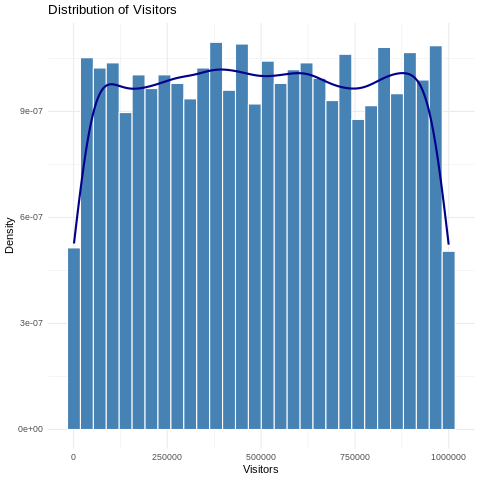

In [25]:
%%R
ggplot(df, aes(x = Visitors)) +
  geom_histogram(aes(y = after_stat(density)), bins = 30, fill = "steelblue", color = "white") +
  geom_density(color = "darkblue", linewidth = 1) +
  labs(title = "Distribution of Visitors", x = "Visitors", y = "Density") +
  theme_minimal()

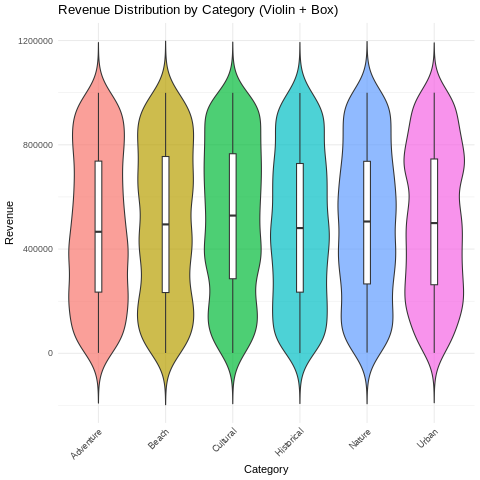

In [29]:
%%R
ggplot(df, aes(x = Category, y = Revenue, fill = Category)) +
  geom_violin(trim = FALSE, alpha = 0.7) +
  geom_boxplot(width = 0.1, fill = "white") +
  labs(title = "Revenue Distribution by Category (Violin + Box)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

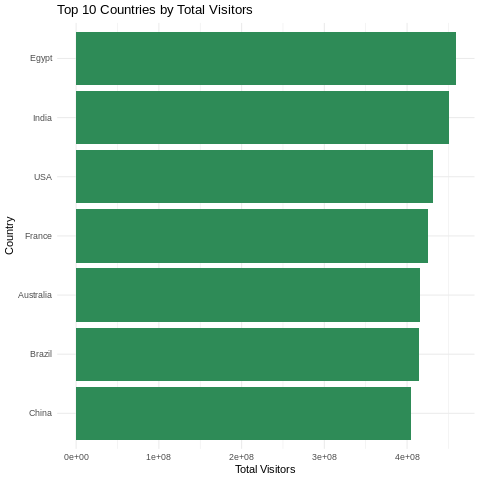

In [32]:
%%R
top_countries <- df %>%
  group_by(Country) %>%
  summarise(total_visitors = sum(Visitors)) %>%
  arrange(desc(total_visitors)) %>%
  head(10)

ggplot(top_countries, aes(x = reorder(Country, total_visitors), y = total_visitors)) +
  geom_col(fill = "seagreen") +
  coord_flip() +
  labs(title = "Top 10 Countries by Total Visitors", x = "Country", y = "Total Visitors") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


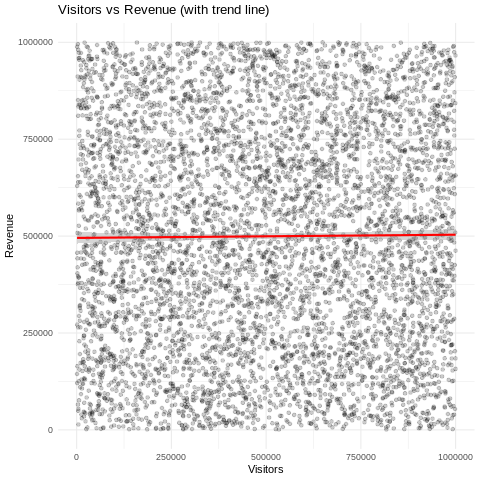

In [33]:
%%R
ggplot(df, aes(x = Visitors, y = Revenue, color = Category)) +
  geom_point(alpha = 0.4) +
  labs(title = "Visitors vs Revenue by Category") +
  theme_minimal()

# With trend line
ggplot(df, aes(x = Visitors, y = Revenue)) +
  geom_point(alpha = 0.2) +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Visitors vs Revenue (with trend line)") +
  theme_minimal()

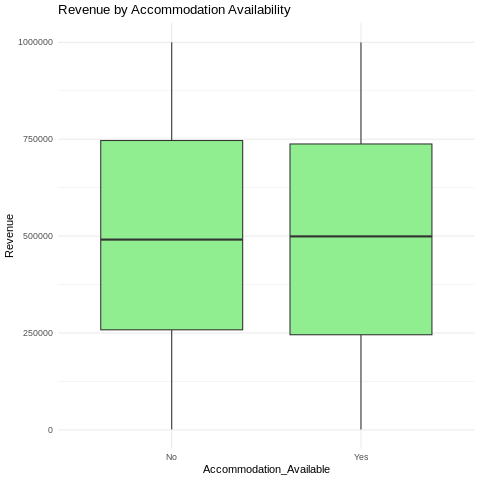

In [34]:
%%R
ggplot(df, aes(x = Category, y = Rating)) +
  geom_boxplot(fill = "lightblue") +
  labs(title = "Rating Distribution by Category") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ggplot(df, aes(x = Accommodation_Available, y = Revenue)) +
  geom_boxplot(fill = "lightgreen") +
  labs(title = "Revenue by Accommodation Availability") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'


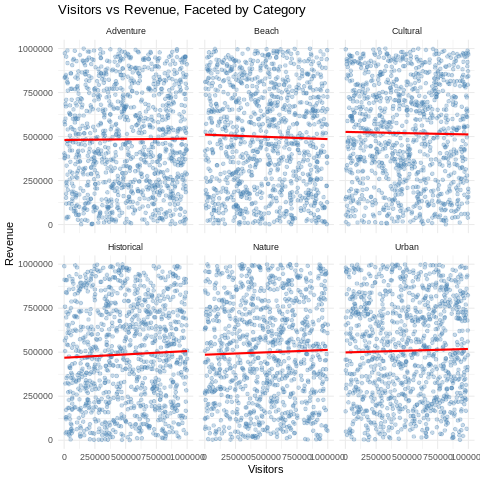

In [37]:
%%R
ggplot(df, aes(x = Visitors, y = Revenue)) +
  geom_point(alpha = 0.3, color = "steelblue") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  facet_wrap(~ Category) +
  labs(title = "Visitors vs Revenue, Faceted by Category") +
  theme_minimal()

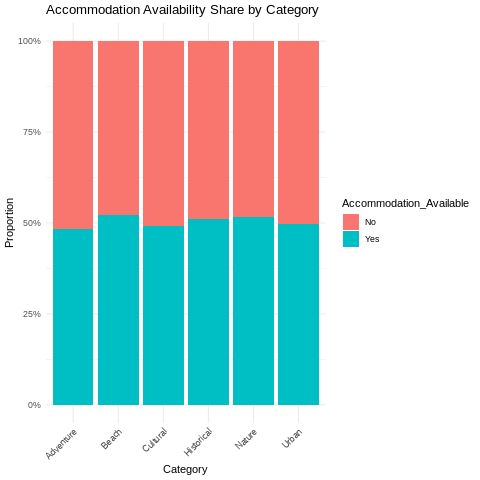

In [38]:
%%R
ggplot(df, aes(x = Category, fill = Accommodation_Available)) +
  geom_bar(position = "fill") +
  labs(title = "Accommodation Availability Share by Category", y = "Proportion") +
  scale_y_continuous(labels = scales::percent) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

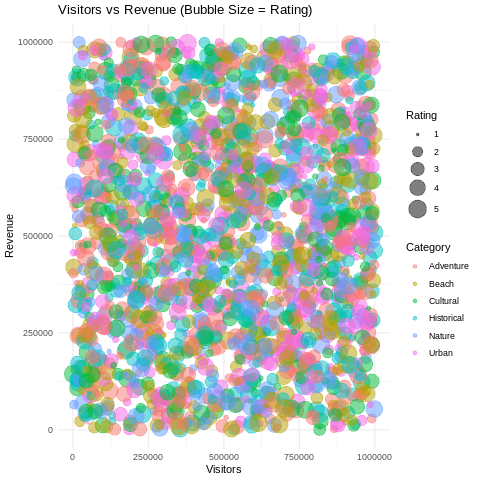

In [41]:
%%R
 ggplot(df %>% sample_n(2000), aes(x = Visitors, y = Revenue, size = Rating, color = Category)) +
  geom_point(alpha = 0.5) +
  scale_size_continuous(range = c(1, 8)) +
  labs(title = "Visitors vs Revenue (Bubble Size = Rating)") +
  theme_minimal()

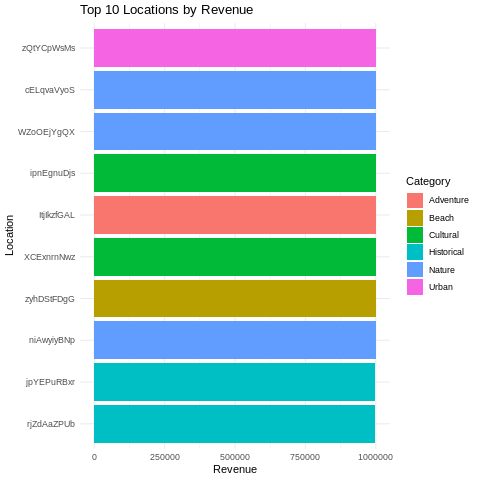

In [45]:
%%R
top_locations <- df %>%
  arrange(desc(Revenue)) %>%
  head(10)

ggplot(top_locations, aes(x = reorder(Location, Revenue), y = Revenue, fill = Category)) +
  geom_col() +
  coord_flip() +
  labs(title = "Top 10 Locations by Revenue", x = "Location", y = "Revenue") +
  theme_minimal()

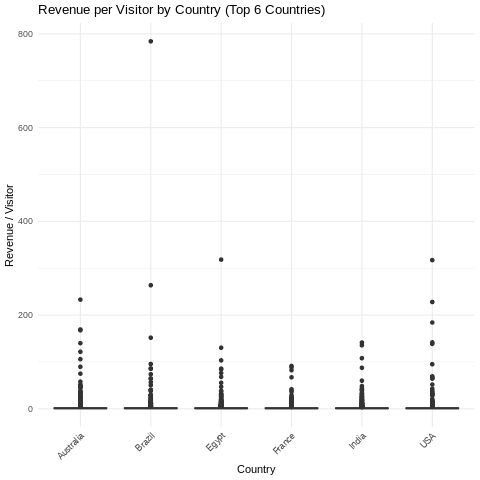

In [44]:
%%R
df_top_countries <- df %>%
  filter(Country %in% (df %>% count(Country, sort = TRUE) %>% head(6) %>% pull(Country))) %>%
  mutate(revenue_per_visitor = Revenue / Visitors)

ggplot(df_top_countries, aes(x = Country, y = revenue_per_visitor, fill = Country)) +
  geom_boxplot() +
  labs(title = "Revenue per Visitor by Country (Top 6 Countries)", y = "Revenue / Visitor") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1), legend.position = "none")

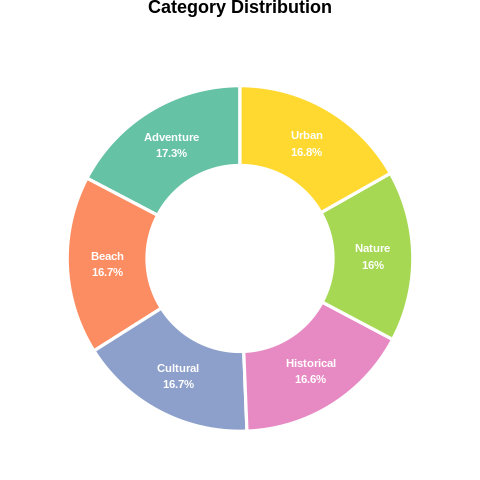

In [46]:
%%R
category_counts <- df %>%
  count(Category) %>%
  mutate(
    percentage = n / sum(n) * 100,
    label = paste0(Category, "\n", round(percentage, 1), "%")
  )

ggplot(category_counts, aes(x = 2, y = n, fill = Category)) +
  geom_col(color = "white", linewidth = 1.5) +
  coord_polar(theta = "y") +
  xlim(0.5, 2.5) +
  geom_text(aes(label = label), position = position_stack(vjust = 0.5),
            color = "white", size = 4, fontface = "bold") +
  scale_fill_brewer(palette = "Set2") +
  labs(title = "Category Distribution") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold", margin = margin(b = 20)),
    legend.position = "none"
  )

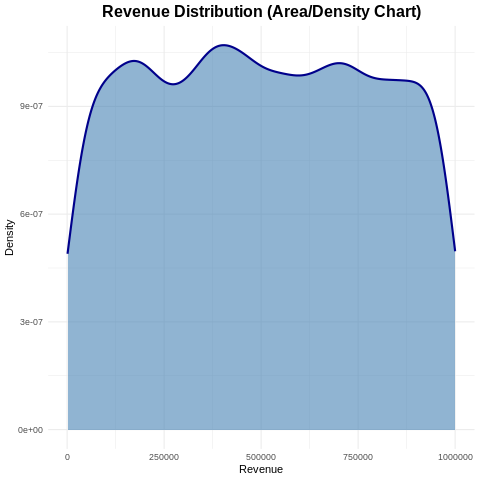

In [49]:
%%R
ggplot(df, aes(x = Revenue)) +
  geom_density(fill = "steelblue", alpha = 0.6, color = "darkblue", linewidth = 1) +
  labs(title = "Revenue Distribution (Area/Density Chart)", x = "Revenue", y = "Density") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

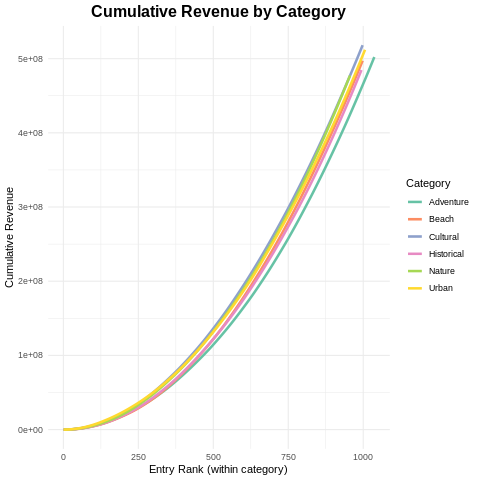

In [50]:
%%R
cumulative_df <- df %>%
  arrange(Category, Revenue) %>%
  group_by(Category) %>%
  mutate(rank = row_number(), cumulative_revenue = cumsum(Revenue)) %>%
  ungroup()

ggplot(cumulative_df, aes(x = rank, y = cumulative_revenue, color = Category)) +
  geom_line(linewidth = 1.2) +
  labs(title = "Cumulative Revenue by Category", x = "Entry Rank (within category)", y = "Cumulative Revenue") +
  scale_color_brewer(palette = "Set2") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

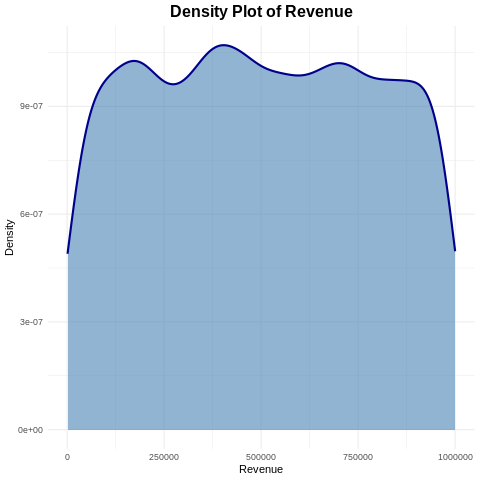

In [51]:
%%R
ggplot(df, aes(x = Revenue)) +
  geom_density(fill = "steelblue", alpha = 0.6, color = "darkblue", linewidth = 1) +
  labs(title = "Density Plot of Revenue", x = "Revenue", y = "Density") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

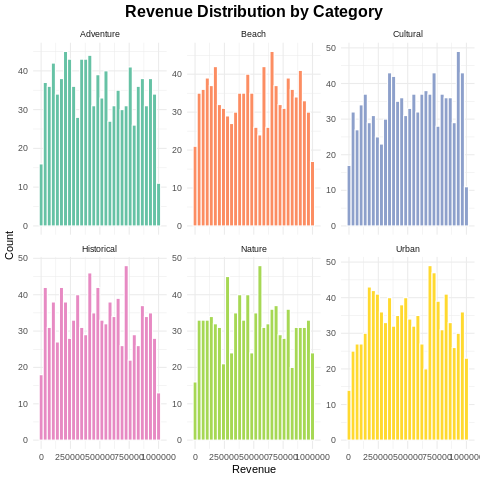

In [52]:
%%R
ggplot(df, aes(x = Revenue, fill = Category)) +
  geom_histogram(bins = 30, color = "white") +
  facet_wrap(~ Category, scales = "free_y") +
  labs(title = "Revenue Distribution by Category", x = "Revenue", y = "Count") +
  scale_fill_brewer(palette = "Set2") +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
    legend.position = "none"
  )

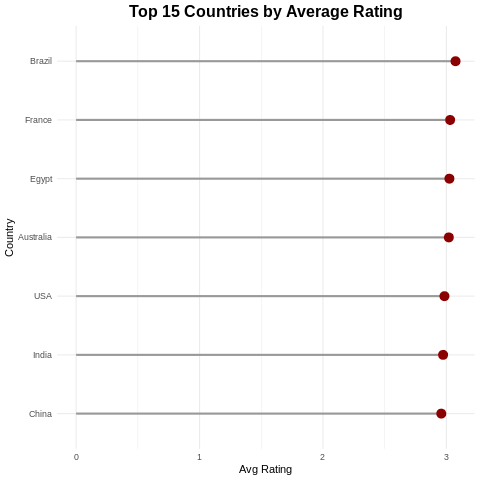

In [53]:
%%R
country_rating <- df %>%
  group_by(Country) %>%
  summarise(avg_rating = mean(Rating)) %>%
  arrange(desc(avg_rating)) %>%
  head(15)

ggplot(country_rating, aes(x = reorder(Country, avg_rating), y = avg_rating)) +
  geom_segment(aes(xend = Country, y = 0, yend = avg_rating), color = "grey60", linewidth = 1) +
  geom_point(size = 4, color = "darkred") +
  coord_flip() +
  labs(title = "Top 15 Countries by Average Rating", x = "Country", y = "Avg Rating") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

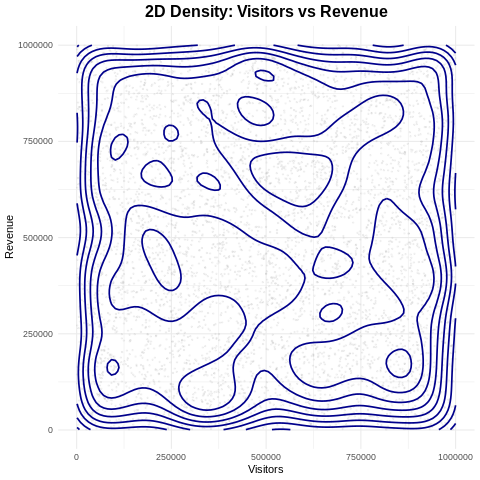

In [54]:
%%R
ggplot(df, aes(x = Visitors, y = Revenue)) +
  geom_point(alpha = 0.1, color = "grey60", size = 0.5) +
  geom_density_2d(color = "darkblue", linewidth = 0.8) +
  labs(title = "2D Density: Visitors vs Revenue", x = "Visitors", y = "Revenue") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

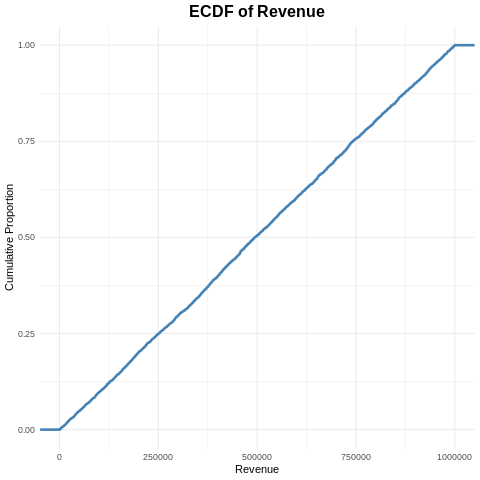

In [55]:
%%R
ggplot(df, aes(x = Revenue)) +
  stat_ecdf(geom = "step", color = "steelblue", linewidth = 1.2) +
  labs(title = "ECDF of Revenue", x = "Revenue", y = "Cumulative Proportion") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))